# Random Forest Classifier - Phishing Site Detection

In this notebook I train a Random Forest model to detect phishing URLs. Compared to the old version I use a bigger sample of 100,000 rows, more trees (200 instead of 100), TF-IDF instead of CountVectorizer, and I added 6 extra URL features.

## 1. Import Libraries

In [1]:
import os
import pickle
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

## 2. Configuration

All the settings are here in one dictionary. I change this cell if I want to try different values.

In [2]:
CONFIG = {
    "data_path":          "../preprocessing-dataset/processed_data.csv",
    "result_dir":         "result",
    "url_column":         "URL",
    "text_column":        "processed_text",
    "label_column":       "Label",
    "sample_size":        100_000,
    "test_size":          0.2,
    "random_state":       42,
    "svd_components":     200,
    "n_estimators":       200,
    "max_depth":          None,
    "class_weight":       "balanced",
    "min_samples_split":  2,
}

os.makedirs(CONFIG["result_dir"], exist_ok=True)

## 3. URL Feature Function

Here I define a function that takes a URL and returns 6 numbers. These are simple things like the length of the URL or whether it contains an IP address.

In [3]:
def extract_url_features(url: str) -> list[float]:
    """Extract handcrafted numeric features from a raw URL string.

    Args:
        url: Raw URL string (may be missing scheme).

    Returns:
        A list of six numeric features:
        [url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth].
    """
    url = str(url)
    has_ip = 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0
    subdomain_depth = (
        max(0, len(url.split('/')[2].split('.')) - 2)
        if '//' in url else 0
    )
    return [
        len(url),
        url.count('.'),
        sum(c.isdigit() for c in url),
        sum(c in '@-_=?&' for c in url),
        has_ip,
        subdomain_depth,
    ]

## 4. Load the Data

I load the CSV file and take a random sample of 100,000 rows. Then I extract the URL features right away before splitting.

In [4]:
df = pd.read_csv(CONFIG["data_path"])
print(f"Full dataset shape: {df.shape}")

df = df.sample(n=CONFIG["sample_size"], random_state=CONFIG["random_state"]).reset_index(drop=True)
print(f"Sampled dataset shape: {df.shape}")
print(f"Label distribution:\n{df[CONFIG['label_column']].value_counts()}")

url_features = np.array(
    [extract_url_features(u) for u in df[CONFIG["url_column"]]],
    dtype=np.float32,
)
print(f"URL feature matrix shape: {url_features.shape}")
df.head()

Full dataset shape: (549346, 3)
Sampled dataset shape: (100000, 3)
Label distribution:
Label
good    71629
bad     28371
Name: count, dtype: int64
URL feature matrix shape: (100000, 6)


,URL,Label,processed_text
0,tubevector.com/search/?q=erika,good,tubevector com search q erika
1,classmates.com/directory/school/Marian%20Chris...,good,classmat com directori school marian 20christi...
2,isgsi.com/office/adb/c58c94eccbfb951bd4ba5f2a6...,bad,isgsi com offic adb c58c94eccbfb951bd4ba5f2a62...
3,manufacturersnews.com/executives.asp?start=CEN,good,manufacturersnew com execut asp start cen
4,'9d345009-a-62cb3a1a-s-sites.googlegroups.com/...,bad,9d345009 a 62cb3a1a s site googlegroup com sit...


## 5. Split the Data

I split on index so that the text, URL features, and labels all use the same 80/20 split.

In [5]:
y = df[CONFIG["label_column"]].values
idx = np.arange(len(df))

train_idx, test_idx = train_test_split(
    idx,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y,
)

y_train, y_test     = y[train_idx], y[test_idx]
url_train, url_test = url_features[train_idx], url_features[test_idx]

text_train = df.iloc[train_idx][CONFIG["text_column"]].fillna("").astype(str).values
text_test  = df.iloc[test_idx][CONFIG["text_column"]].fillna("").astype(str).values

print(f"Training samples : {len(train_idx)}")
print(f"Test samples     : {len(test_idx)}")

Training samples : 80000
Test samples     : 20000


## 6. TF-IDF Vectorization

I fit `TfidfVectorizer` on the training text only and then transform the test set. This makes sure the test data does not influence the vocabulary.

In [6]:
tfidf = TfidfVectorizer()
x_train_tfidf = tfidf.fit_transform(text_train)
x_test_tfidf  = tfidf.transform(text_test)

print(f"TF-IDF vocabulary size : {len(tfidf.vocabulary_)}")
print(f"Train TF-IDF shape     : {x_train_tfidf.shape}")
print(f"Test  TF-IDF shape     : {x_test_tfidf.shape}")

TF-IDF vocabulary size : 112298
Train TF-IDF shape     : (80000, 112298)
Test  TF-IDF shape     : (20000, 112298)


## 7. Reduce Dimensions with SVD

I use `TruncatedSVD` to reduce the TF-IDF matrix from a very high number of columns down to 200. I fit it on training data only.

In [7]:
svd = TruncatedSVD(n_components=CONFIG["svd_components"], random_state=CONFIG["random_state"])
x_train_svd = svd.fit_transform(x_train_tfidf)
x_test_svd  = svd.transform(x_test_tfidf)

explained = svd.explained_variance_ratio_.sum()
print(f"SVD dims               : {x_train_svd.shape[1]}")
print(f"Explained variance     : {explained:.3f}")

SVD dims               : 200
Explained variance     : 0.161


## 8. Combine the Features

I join the 200 SVD columns with the 6 URL features using `np.hstack`. Each sample now has 206 features.

In [8]:
x_train = np.hstack([x_train_svd, url_train])
x_test  = np.hstack([x_test_svd,  url_test])

print(f"Final train feature shape : {x_train.shape}")
print(f"Final test  feature shape : {x_test.shape}")

Final train feature shape : (80000, 206)
Final test  feature shape : (20000, 206)


## 9. Train the Model

I use `RandomForestClassifier` with 200 trees. I add `class_weight=balanced` because there are about 3 times more good URLs than bad ones, and this helps the model pay more attention to the phishing class.

In [9]:
rf = RandomForestClassifier(
    n_estimators=CONFIG["n_estimators"],
    max_depth=CONFIG["max_depth"],
    class_weight=CONFIG["class_weight"],
    min_samples_split=CONFIG["min_samples_split"],
    random_state=CONFIG["random_state"],
    n_jobs=-1,
)
rf.fit(x_train, y_train)
print("Random Forest model trained.")

Random Forest model trained.


## 10. Check the Results

I print the accuracy, the full classification report, and show the confusion matrix.

In [10]:
y_pred   = rf.predict(x_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.9166


In [11]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         bad       0.94      0.75      0.84      5674
        good       0.91      0.98      0.94     14326

    accuracy                           0.92     20000
   macro avg       0.93      0.87      0.89     20000
weighted avg       0.92      0.92      0.91     20000



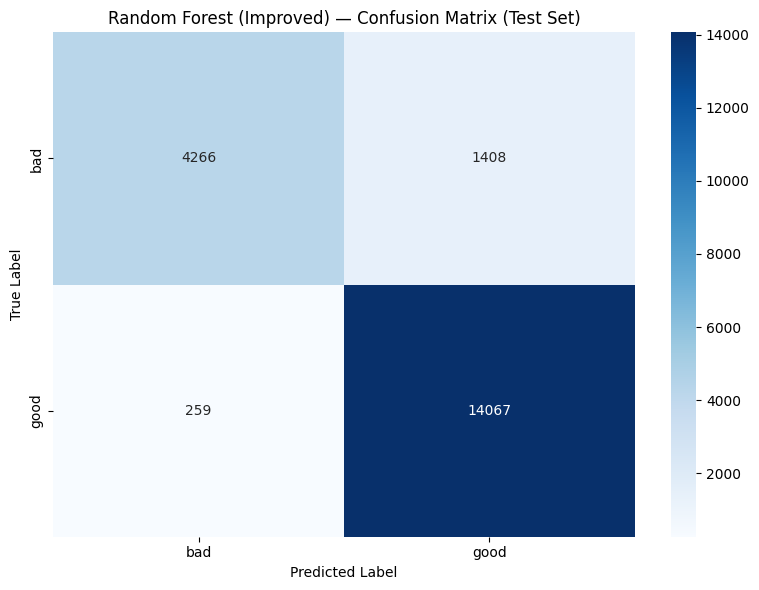

In [12]:
cm     = confusion_matrix(y_test, y_pred)
labels = sorted(set(y))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
)
ax.set_title("Random Forest (Improved) — Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

## 11. Save the Results

I save the model, the classification report text, and the confusion matrix image to the result folder.

In [13]:
model_path = os.path.join(CONFIG["result_dir"], "model_random_forest.pkl")
with open(model_path, "wb") as f:
    pickle.dump(rf, f)
print(f"Model saved to {model_path}")

Model saved to result\model_random_forest.pkl


In [14]:
report_path = os.path.join(CONFIG["result_dir"], "classification_report_random_forest.txt")
with open(report_path, "w") as f:
    f.write(f"Test accuracy: {test_acc:.4f}\n\n")
    f.write(report)
print(f"Classification report saved to {report_path}")

Classification report saved to result\classification_report_random_forest.txt


In [15]:
cm_path = os.path.join(CONFIG["result_dir"], "confusion_matrix_random_forest.png")
fig.savefig(cm_path, dpi=150, bbox_inches="tight")
print(f"Confusion matrix plot saved to {cm_path}")

Confusion matrix plot saved to result\confusion_matrix_random_forest.png
